In [1]:
!nvidia-smi

Fri Apr 17 08:01:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.14                 Driver Version: 566.14         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P8              5W /   65W |     123MiB /   4096MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

In [3]:
import torch
import torchvision

print(f"PyTorch   : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE = 0 if torch.cuda.is_available() else "cpu" 

PyTorch   : 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [4]:
from pathlib import Path

# Thư mục gốc của project 
BASE_PATH = Path(r"D:\yolov26")

DATASET    = BASE_PATH / "dataset_detect"

IMG_TRAIN  = DATASET / "train"  / "images"
LBL_TRAIN  = DATASET / "train"  / "labels"

IMG_TEST   = DATASET / "test"   / "images"
LBL_TEST   = DATASET / "test"   / "labels"

DATA_YAML  = DATASET / "data.yaml"

WEIGHTS    = BASE_PATH / "runs" / "detect" / "train" / "weights" / "best.pt"  

In [5]:
def check_dataset(img_dir: Path, lbl_dir: Path, split: str = ""):
    imgs = {p.stem for p in img_dir.glob("*") if p.is_file()}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}

    missing = imgs - lbls
    extra   = lbls - imgs

    print(f"\n[Dataset Check] {split}")
    print(f"  Images        : {len(imgs)}")
    print(f"  Labels        : {len(lbls)}")
    print(f"  Ảnh không có label: {len(missing)}")
    print(f"  Label có nhưng ảnh thì không : {len(extra)}")
    if missing:
        print(f"  ⚠ Ví dụ thiếu: {list(missing)[:5]}")
    return missing
check_dataset(IMG_TRAIN, LBL_TRAIN, split="train")
check_dataset(IMG_TEST,  LBL_TEST,  split="test")


[Dataset Check] train
  Images        : 877
  Labels        : 877
  Ảnh không có label: 0
  Label có nhưng ảnh thì không : 0

[Dataset Check] test
  Images        : 223
  Labels        : 223
  Ảnh không có label: 0
  Label có nhưng ảnh thì không : 0


set()

In [6]:
for p in [IMG_TRAIN, LBL_TRAIN, IMG_TEST, DATA_YAML]:
    status = "✓" if p.exists() else "✗ KHÔNG TÌM THẤY"
    print(f"  [{status}] {p}")

  [✓] D:\yolov26\dataset_detect\train\images
  [✓] D:\yolov26\dataset_detect\train\labels
  [✓] D:\yolov26\dataset_detect\test\images
  [✓] D:\yolov26\dataset_detect\data.yaml


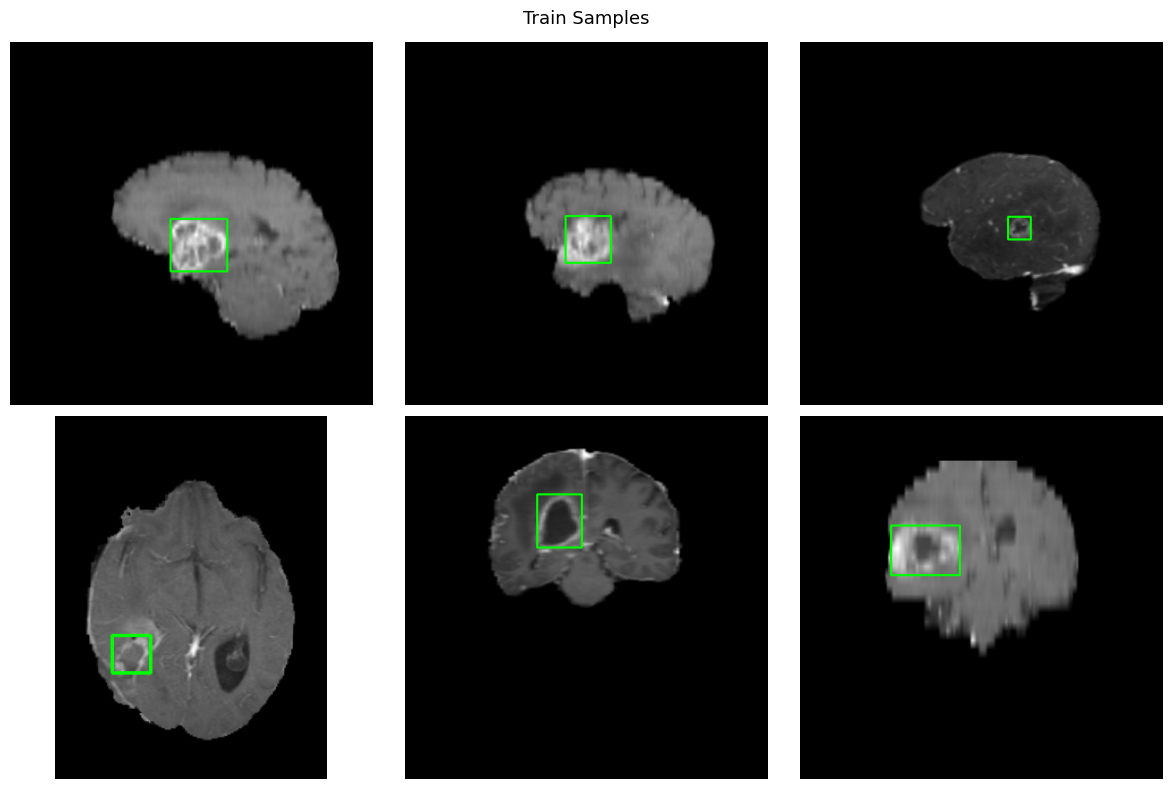

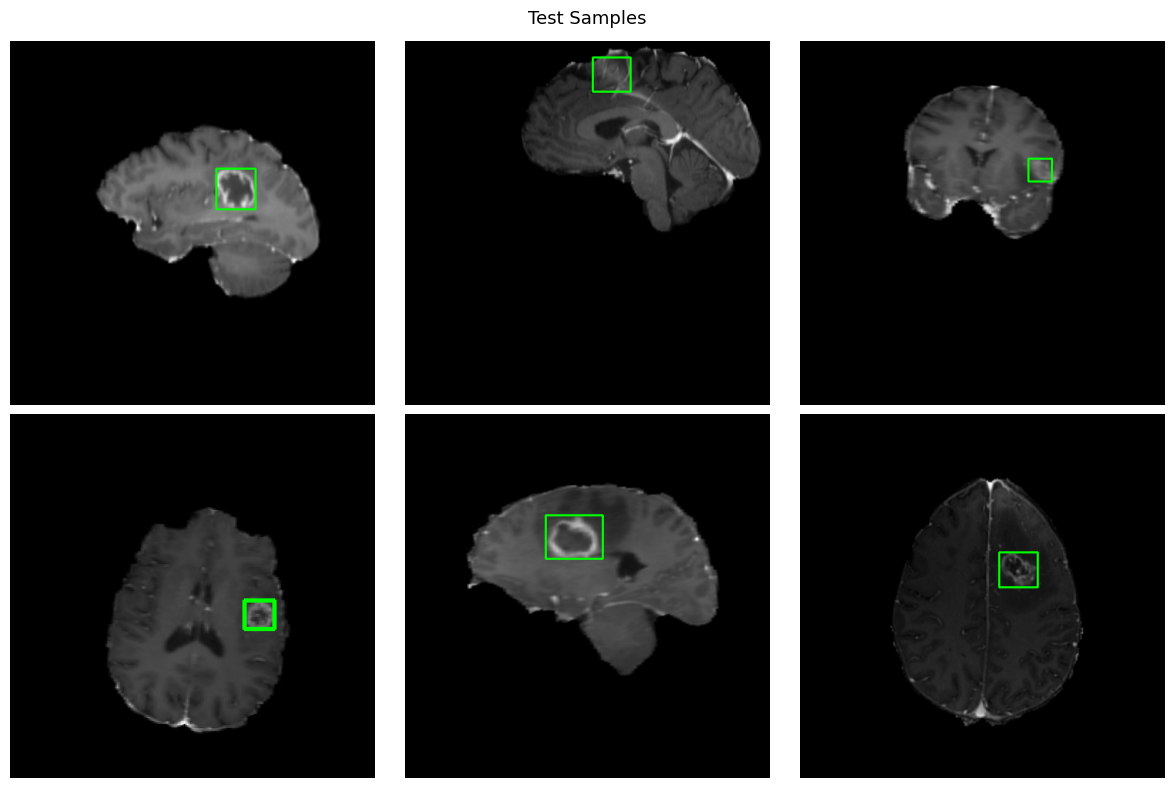

In [7]:
import cv2
import random
import matplotlib.pyplot as plt

def show_samples(img_dir: Path, lbl_dir: Path, n: int = 6, title: str = ""):
    imgs = [p for p in img_dir.glob("*") if p.is_file()]
    if not imgs:
        print(f"Không tìm thấy ảnh trong: {img_dir}")
        return

    n    = min(n, len(imgs))
    cols = 3
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(12, 4 * rows))
    plt.suptitle(title or str(img_dir), fontsize=13)

    for i, img_path in enumerate(random.sample(imgs, n)):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls, x, y, bw, bh = map(float, parts)
                    x1 = int((x - bw / 2) * w)
                    y1 = int((y - bh / 2) * h)
                    x2 = int((x + bw / 2) * w)
                    y2 = int((y + bh / 2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(IMG_TRAIN, LBL_TRAIN, n=6, title="Train Samples")
show_samples(IMG_TEST,  LBL_TEST,  n=6, title="Test Samples")

In [8]:
from ultralytics import YOLO
import torch

def train_binary_tumor():
    # 1. Kiểm tra thiết bị (GPU 1650 của bạn sẽ được nhận là '0')
    device = '0' if torch.cuda.is_available() else 'cpu'
    print(f"🚀 Đang khởi chạy với device: {device}")

    # 2. Khởi tạo mô hình - Sử dụng file yolo26n.pt có sẵn trong thư mục
    model = YOLO("yolo26s.pt") 

    print("Bắt đầu quá trình huấn luyện...")
    
    # 3. Bắt đầu huấn luyện
    model.train(
        # SỬA LỖI TẠI ĐÂY: Dùng đường dẫn tuyệt đối để máy luôn tìm thấy file
        data=r"D:\yolov26\dataset_detect\data.yaml", 
        
        epochs=50,
        imgsz=640,
        batch=8,           
        device=device,
        workers=0,         # Quan trọng: Trên Windows phải để = 0
        cache=False,
        project="runs/detect",
        name="tumor_pos_neg_yolo26s", 
        
        # --- CÁC THAM SỐ TỐI ƯU ---
        patience=30,
        optimizer="MuSGD",
        lr0=0.001,
        cos_lr=True,
        mosaic=1.0,
        mixup=0.1,
        # label_smoothing=0.1, <-- Đã ẩn dòng này vì phiên bản YOLO mới không dùng nữa
        plots=True
    )
    
    print("✅ Huấn luyện xong! Kiểm tra kết quả trong thư mục runs/detect/")

# Khối lệnh bắt buộc để chạy trên Windows
if __name__ == '__main__':
    train_binary_tumor()

🚀 Đang khởi chạy với device: 0
Bắt đầu quá trình huấn luyện...
New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\yolov26\dataset_detect\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=